In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

2026-02-27 08:09:05.724366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772179745.960812      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772179746.027550      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772179746.570988      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772179746.571030      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772179746.571033      55 computation_placer.cc:177] computation placer alr

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


In [3]:
DATASET_PATH = "/kaggle/input/datasets/mohithbacha/diabetes-detection"

train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 2076 images belonging to 2 classes.
Found 531 images belonging to 2 classes.
Found 231 images belonging to 2 classes.
{'DR': 0, 'No_DR': 1}


In [6]:
def double_conv(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x


def build_unet_classifier(input_shape=(224,224,3), num_classes=2):
    
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = double_conv(inputs, 64)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = double_conv(p1, 128)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = double_conv(p2, 256)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = double_conv(p3, 512)

    # Classification Head
    gap = layers.GlobalAveragePooling2D()(c4)
    dense1 = layers.Dense(128, activation='relu')(gap)
    dropout = layers.Dropout(0.5)(dense1)
    outputs = layers.Dense(num_classes, activation='softmax')(dropout)

    model = models.Model(inputs, outputs)
    return model

In [7]:
model = build_unet_classifier()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1772179827.719418      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772179827.725223      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             

 Total params: 4,758,978 (18.15 MB)

 Trainable params: 4,755,138 (18.14 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [8]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1772179845.526723     159 service.cc:152] XLA service 0x7bb414008bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772179845.526759     159 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772179845.526763     159 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772179846.534940     159 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-27 08:10:56.896183: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 08:10:57.080594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 08:10:58.031323: E external/local_xl

125/130 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.7513 - loss: 0.5519

2026-02-27 08:11:55.005229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 08:11:55.190400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 08:11:56.104230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 08:11:56.268525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-27 08:11:57.950668: E external/local_xla/xla/stream_

130/130 ━━━━━━━━━━━━━━━━━━━━ 100s 554ms/step - accuracy: 0.7540 - loss: 0.5469 - val_accuracy: 0.5386 - val_loss: 0.6915
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 230ms/step - accuracy: 0.9077 - loss: 0.2553 - val_accuracy: 0.4614 - val_loss: 0.9881
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s 236ms/step - accuracy: 0.8975 - loss: 0.2621 - val_accuracy: 0.6667 - val_loss: 0.6002
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 230ms/step - accuracy: 0.9106 - loss: 0.2600 - val_accuracy: 0.5763 - val_loss: 0.6344
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.9098 - loss: 0.2444 - val_accuracy: 0.8004 - val_loss: 0.6312
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 231ms/step - accuracy: 0.9054 - loss: 0.2575 - val_accuracy: 0.9002 - val_loss: 0.2722
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 232ms/step - accuracy: 0.9185 - loss: 0.2197 - val_accuracy: 0.9379 - val_loss: 0.1838
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 30s 230ms/step - accuracy: 0.9281 - loss: 0.1848 - va

In [9]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc * 100)

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 398ms/step - accuracy: 0.9052 - loss: 0.2454
Test Accuracy: 91.77489280700684


In [10]:
model.save("unet_dr_model.h5")

In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Get true labels
true_labels = test_generator.classes

# Predict probabilities
predictions = model.predict(test_generator)

# Convert probabilities to class index
predicted_labels = np.argmax(predictions, axis=1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step


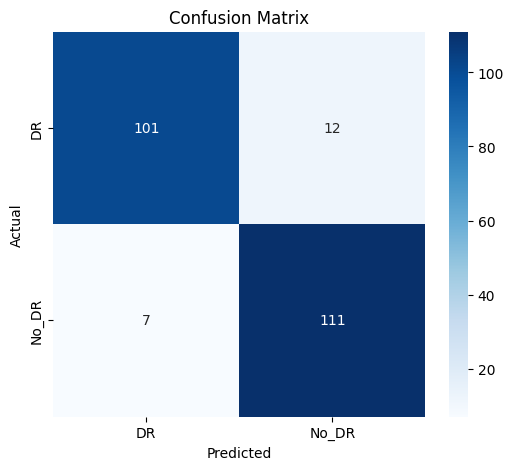

In [13]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=list(test_generator.class_indices.keys())
)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

          DR       0.94      0.89      0.91       113
       No_DR       0.90      0.94      0.92       118

    accuracy                           0.92       231
   macro avg       0.92      0.92      0.92       231
weighted avg       0.92      0.92      0.92       231



In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels, average='weighted')
recall = recall_score(true_labels, predicted_labels, average='weighted')
f1 = f1_score(true_labels, predicted_labels, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9177489177489178
Precision: 0.9184577091081156
Recall   : 0.9177489177489178
F1 Score : 0.9176717026363109


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [17]:
# Overall accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

# Class-wise metrics
precision = precision_score(true_labels, predicted_labels, average=None)
recall = recall_score(true_labels, predicted_labels, average=None)
f1 = f1_score(true_labels, predicted_labels, average=None)

class_names = list(test_generator.class_indices.keys())

print("Accuracy:", accuracy)
print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1 per class:", f1)

Accuracy: 0.9177489177489178
Precision per class: [0.93518519 0.90243902]
Recall per class: [0.89380531 0.94067797]
F1 per class: [0.91402715 0.92116183]


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Overall accuracy
accuracy = accuracy_score(true_labels, predicted_labels)

# Class-wise metrics
precision = precision_score(true_labels, predicted_labels, average=None)
recall = recall_score(true_labels, predicted_labels, average=None)
f1 = f1_score(true_labels, predicted_labels, average=None)

class_names = list(test_generator.class_indices.keys())

print("Classes:", class_names)
print("Accuracy:", accuracy)

Classes: ['DR', 'No_DR']
Accuracy: 0.9177489177489178


Disease class: DR


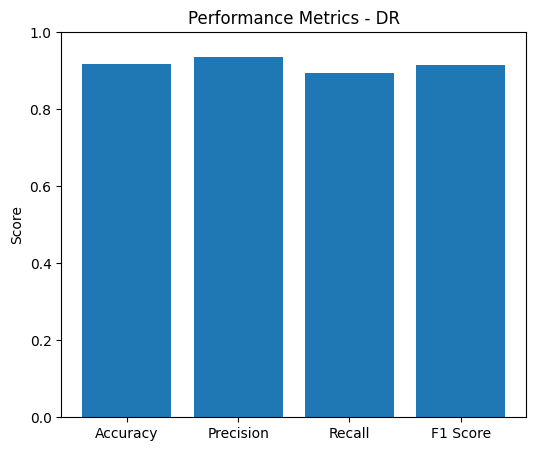

In [24]:
# Detect Disease class properly
dr_index = None

for i, name in enumerate(class_names):
    name_lower = name.lower()
    if "dr" in name_lower and "no" not in name_lower:
        dr_index = i

print("Disease class:", class_names[dr_index])

dr_metrics = [
    accuracy,
    precision[dr_index],
    recall[dr_index],
    f1[dr_index]
]

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(6,5))
plt.bar(metric_names, dr_metrics)

plt.ylim(0,1)
plt.title(f"Performance Metrics - {class_names[dr_index]}")
plt.ylabel("Score")

plt.show()

No Disease class index: 1


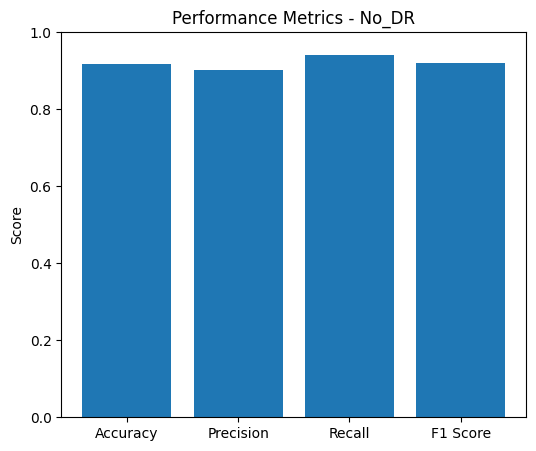

In [23]:
# Find no disease class automatically
nodr_index = None

for i, name in enumerate(class_names):
    if "no" in name.lower():
        nodr_index = i

print("No Disease class index:", nodr_index)

nodr_metrics = [
    accuracy,
    precision[nodr_index],
    recall[nodr_index],
    f1[nodr_index]
]

plt.figure(figsize=(6,5))
plt.bar(metric_names, nodr_metrics)

plt.ylim(0,1)
plt.title(f"Performance Metrics - {class_names[nodr_index]}")
plt.ylabel("Score")

plt.show()

In [25]:
import os

output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

print("Output folder created!")

Output folder created!


In [26]:
model.save(os.path.join(output_dir, "unet_dr_model.h5"))
print("Model saved!")

Model saved!


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
plt.close()

print("Confusion matrix saved!")

Confusion matrix saved!


In [28]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

plt.figure(figsize=(6,5))
plt.bar(metric_names, dr_metrics)
plt.ylim(0,1)
plt.title(f"Performance - {class_names[dr_index]}")
plt.ylabel("Score")

plt.savefig(os.path.join(output_dir, "disease_metrics.png"))
plt.close()

print("Disease graph saved!")

Disease graph saved!


In [29]:
plt.figure(figsize=(6,5))
plt.bar(metric_names, nodr_metrics)
plt.ylim(0,1)
plt.title(f"Performance - {class_names[nodr_index]}")
plt.ylabel("Score")

plt.savefig(os.path.join(output_dir, "no_disease_metrics.png"))
plt.close()

print("No disease graph saved!")

No disease graph saved!


In [30]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
)

with open(os.path.join(output_dir, "classification_report.txt"), "w") as f:
    f.write(report)

print("Classification report saved!")

Classification report saved!


In [31]:
import shutil

shutil.make_archive("/kaggle/working/major_project_results", 'zip', output_dir)

print("All files zipped successfully!")

All files zipped successfully!
